# São Paulo Road Network Analysis

**Pedro Borges** — pedro.borges@inpe.br

Geospatial network analysis of the road infrastructure in the City of São Paulo. This notebook presents the results of the analysis pipeline, including global network statistics, node/edge-level parameters, and spatial aggregations by OD zone, district, and subprefecture.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import pandas as pd
import re
from pathlib import Path

plt.rcParams.update({
    "figure.facecolor": "#1a1a2e",
    "axes.facecolor": "#1a1a2e",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
})

DATA_DIR = Path("data/output")
CRS_WEB_MERCATOR = "EPSG:3857"
BASEMAP = ctx.providers.CartoDB.DarkMatter


def plot_choropleth(gdf, column, title, geom_type="polygon",
                    cmap="plasma", figsize=(12, 10), **kwargs):
    """Plot a choropleth map with a dark basemap."""
    fig, ax = plt.subplots(figsize=figsize)

    plot_kwargs = dict(column=column, cmap=cmap, legend=True,
                       legend_kwds={"shrink": 0.6, "label": column})

    if geom_type == "point":
        plot_kwargs.update(markersize=0.1, alpha=0.6)
    elif geom_type == "line":
        plot_kwargs.update(linewidth=0.15)
    else:
        plot_kwargs.update(alpha=0.7, edgecolor="white", linewidth=0.3)

    plot_kwargs.update(kwargs)
    gdf.plot(ax=ax, **plot_kwargs)

    ctx.add_basemap(ax, source=BASEMAP)
    ax.grid(True, alpha=0.3, color="white", linestyle="--")
    ax.set_axis_off()
    ax.set_title(title, fontsize=14, color="white", pad=12)
    plt.tight_layout()
    plt.show()

## Global Network Parameters

In [2]:
text = (DATA_DIR / "results.txt").read_text()

params = {}
for line in text.splitlines():
    match = re.match(r"^(.+?):\s+([\d.]+)", line.strip())
    if match:
        params[match.group(1).strip()] = match.group(2)

df_params = pd.DataFrame(
    list(params.items()), columns=["Parameter", "Value"]
)
df_params

,Parameter,Value
0,Number of nodes (N),122456
1,Number of edges (L),304027
2,Average degree (<k>),4.9655
3,Average clustering coefficient (<c>),0.0596
4,Average Euclidean distance (<l_eucl>),92.0898
5,Average Manhattan distance (<l_manh>),117.0374
6,Average physical length (<length>),96.9404
7,Topological (edges),114.3566
8,Physical length (m),23144.3021
9,Euclidean distance (m),22754.0413


## Node Parameters

- **k_i** — Node degree: number of edges connected to each node
- **b_i** — Node betweenness centrality: fraction of shortest paths passing through each node
- **c_i** — Clustering coefficient: fraction of a node's neighbors that are also neighbors of each other

In [3]:
nodes = gpd.read_file(DATA_DIR / "nodes.gpkg").to_crs(CRS_WEB_MERCATOR)
nodes[["k_i", "c_i", "b_i", "avg_l_i"]].describe()

,k_i,c_i,b_i,avg_l_i
count,122456.000000,122456.000000,122456.000000,122456.000000
mean,4.965490,0.059641,0.001071,95.989565
std,1.709278,0.127200,0.006706,90.543756
min,1.000000,0.000000,0.000000,0.000000
25%,4.000000,0.000000,0.000020,54.346951
50%,6.000000,0.000000,0.000078,82.972008
75%,6.000000,0.000000,0.000329,116.270134
max,11.000000,1.000000,0.202894,6833.870270


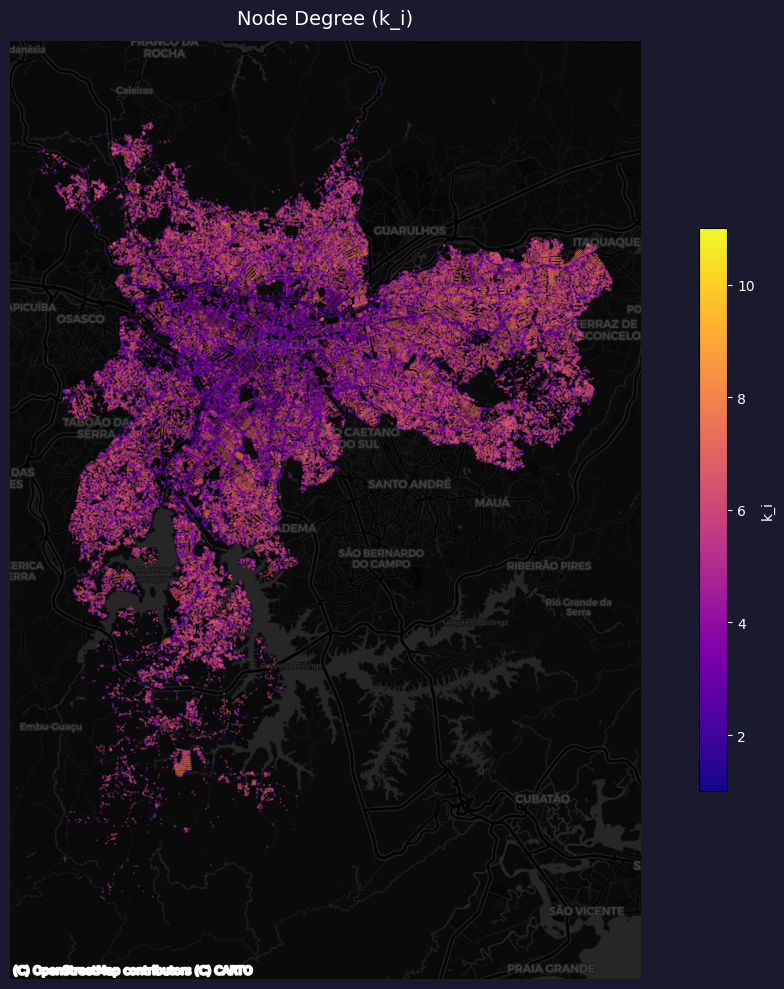

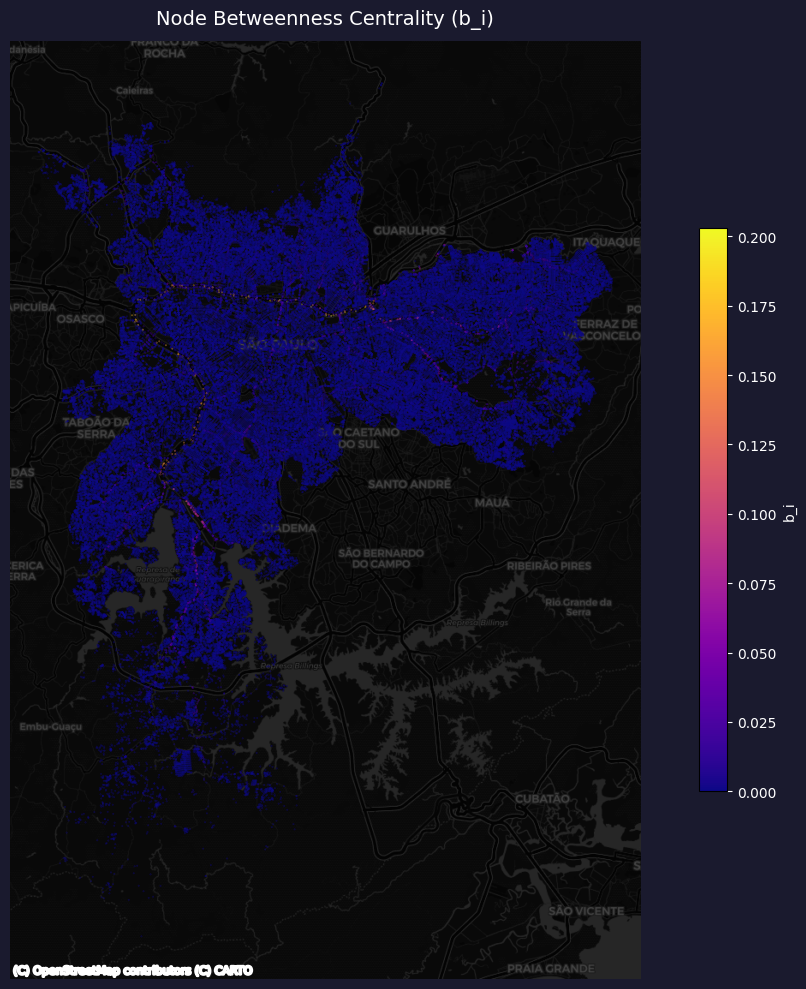

In [4]:
plot_choropleth(nodes, "k_i", "Node Degree (k_i)", geom_type="point")
plot_choropleth(nodes, "b_i", "Node Betweenness Centrality (b_i)", geom_type="point")

## Edge Parameters

- **e_ij** — Edge betweenness centrality: fraction of shortest paths passing through each edge

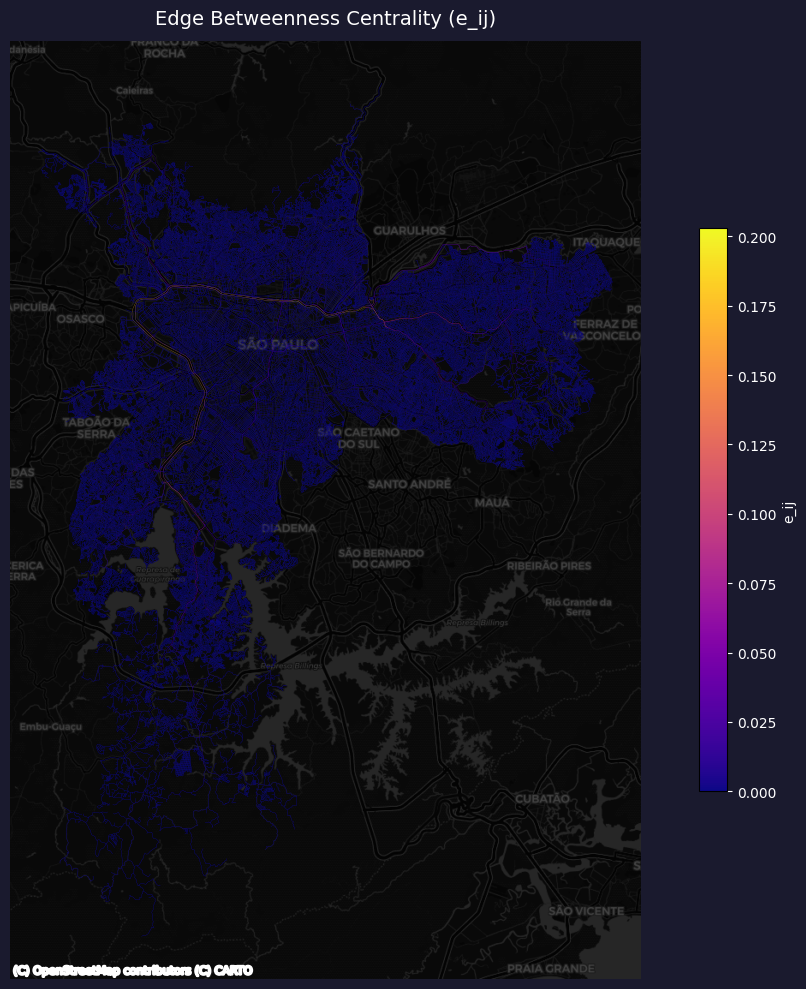

In [5]:
edges = gpd.read_file(DATA_DIR / "edges.gpkg").to_crs(CRS_WEB_MERCATOR)
plot_choropleth(edges, "e_ij", "Edge Betweenness Centrality (e_ij)", geom_type="line")

## Aggregated Parameters by OD Zone

In [ ]:
zones = gpd.read_file(DATA_DIR / "zone_summary.gpkg").to_crs(CRS_WEB_MERCATOR)
plot_choropleth(zones, "k_i_mean", "Mean Node Degree by OD Zone (k_i_mean)")
plot_choropleth(zones, "c_i_mean", "Mean Clustering Coefficient by OD Zone (c_i_mean)")
plot_choropleth(zones, "b_i_mean", "Mean Node Betweenness by OD Zone (b_i_mean)")
plot_choropleth(zones, "e_ij_mean", "Mean Edge Betweenness by OD Zone (e_ij_mean)")
plot_choropleth(zones, "populacao", "Population by OD Zone", cmap="inferno")

## Aggregated Parameters by District

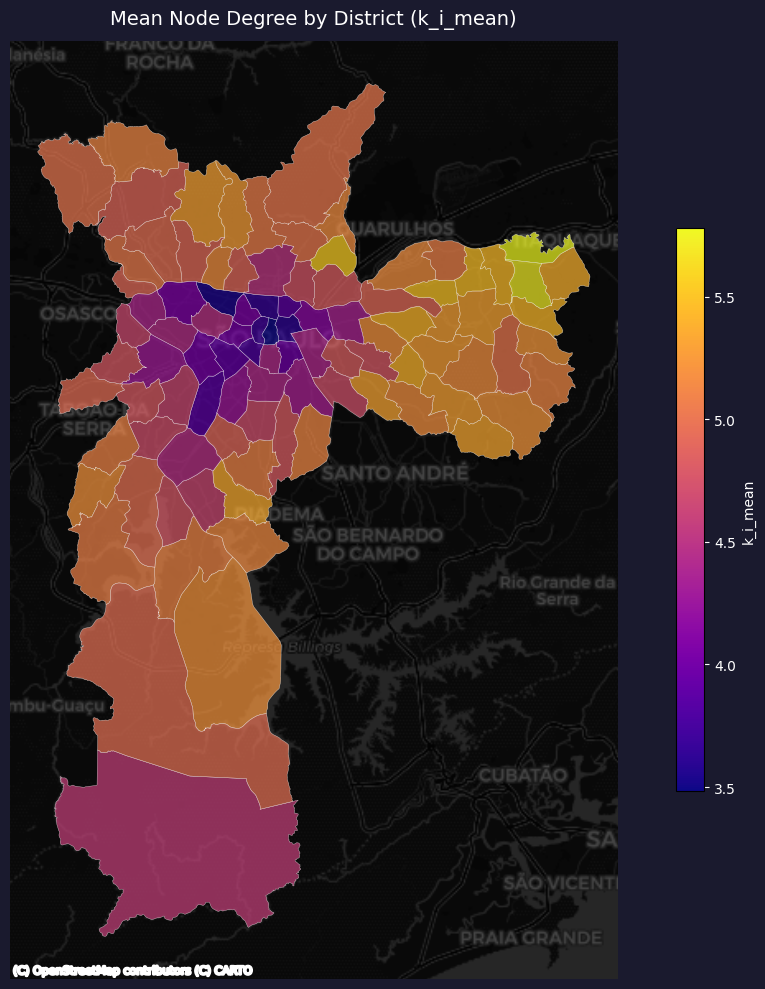

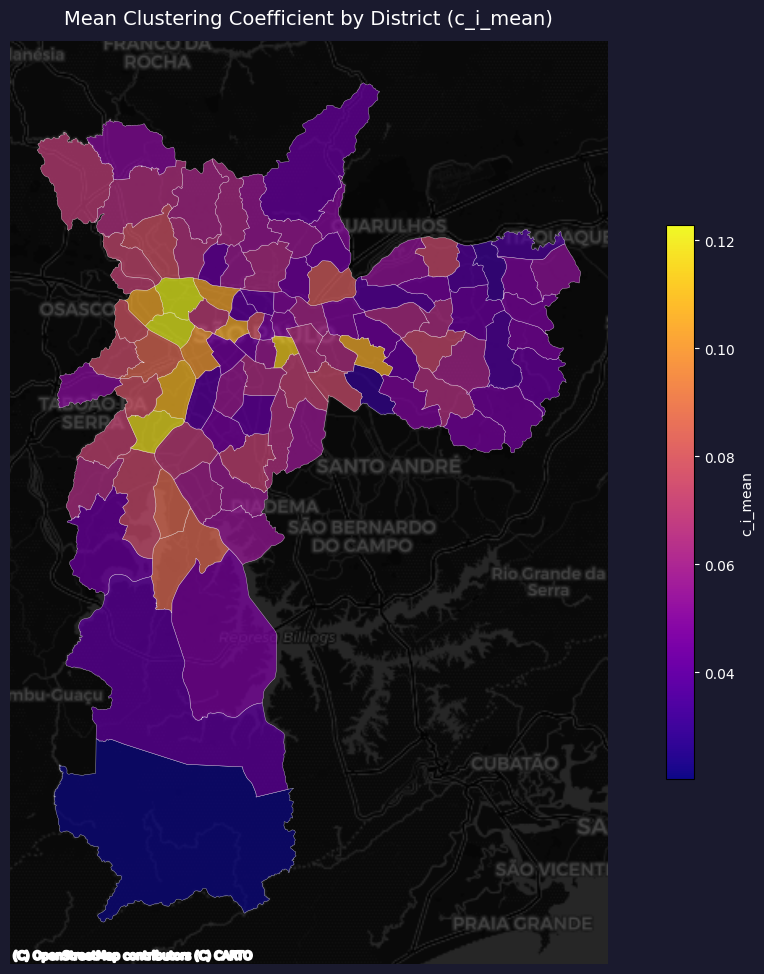

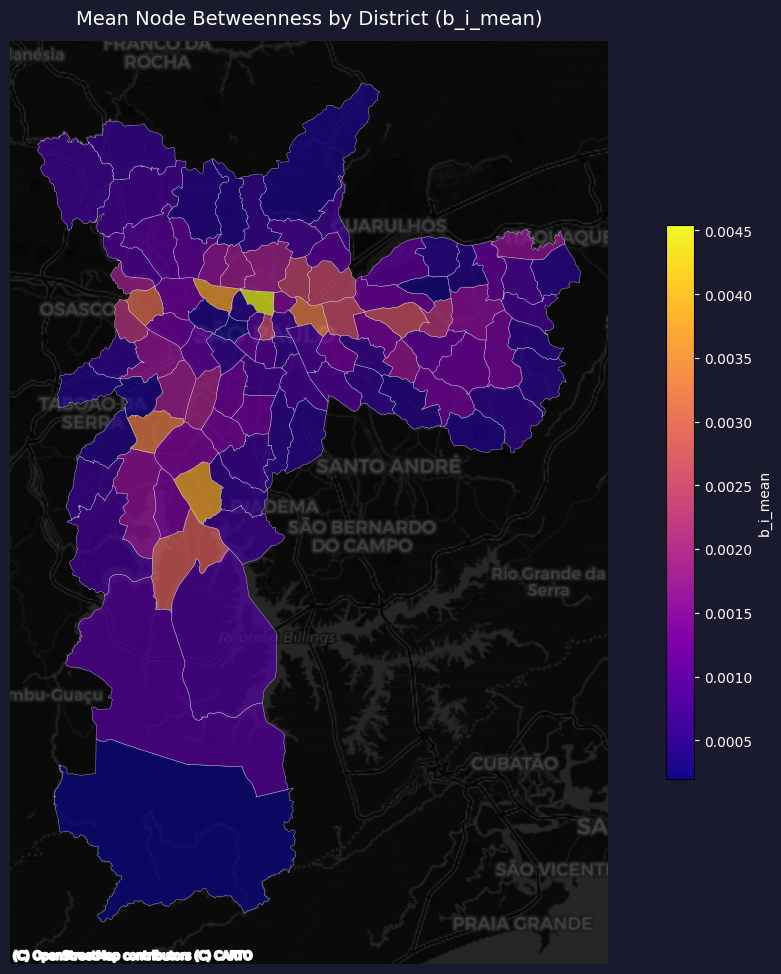

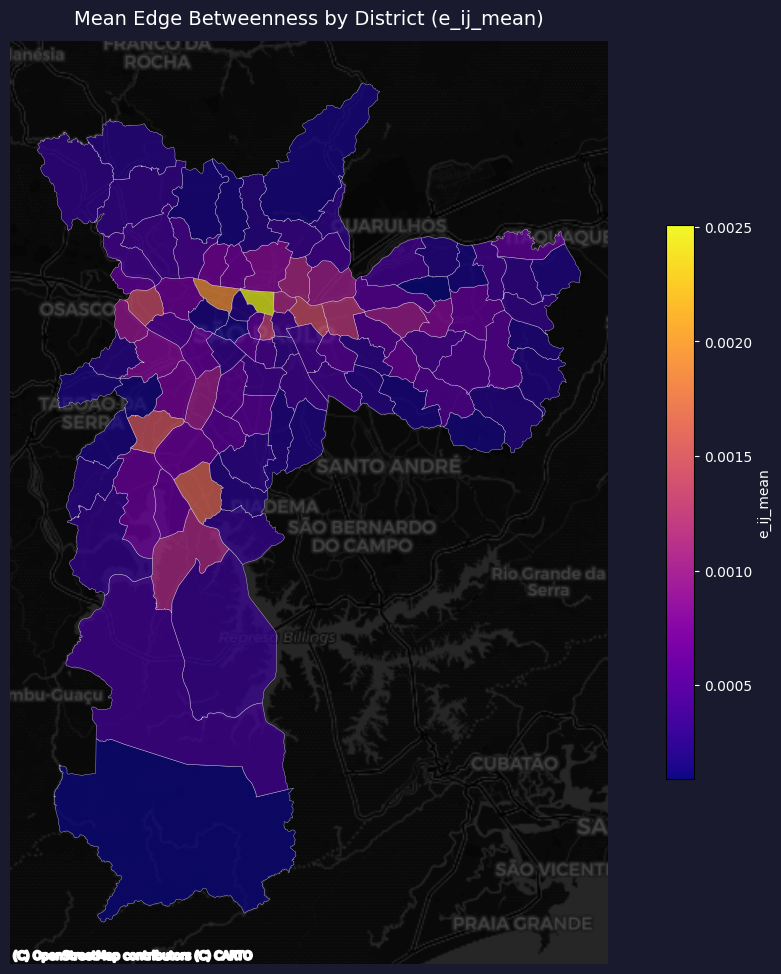

In [7]:
districts = gpd.read_file(DATA_DIR / "district_summary.gpkg").to_crs(CRS_WEB_MERCATOR)
plot_choropleth(districts, "k_i_mean", "Mean Node Degree by District (k_i_mean)")
plot_choropleth(districts, "c_i_mean", "Mean Clustering Coefficient by District (c_i_mean)")
plot_choropleth(districts, "b_i_mean", "Mean Node Betweenness by District (b_i_mean)")
plot_choropleth(districts, "e_ij_mean", "Mean Edge Betweenness by District (e_ij_mean)")

## Aggregated Parameters by Subprefecture

In [ ]:
subpref = gpd.read_file(DATA_DIR / "subprefeitura_summary.gpkg").to_crs(CRS_WEB_MERCATOR)
plot_choropleth(subpref, "k_i_mean", "Mean Node Degree by Subprefecture (k_i_mean)")
plot_choropleth(subpref, "c_i_mean", "Mean Clustering Coefficient by Subprefecture (c_i_mean)")
plot_choropleth(subpref, "b_i_mean", "Mean Node Betweenness by Subprefecture (b_i_mean)")
plot_choropleth(subpref, "e_ij_mean", "Mean Edge Betweenness by Subprefecture (e_ij_mean)")
plot_choropleth(subpref, "populacao", "Population by Subprefecture", cmap="inferno")

In [9]:
subpref_table = (
    subpref
    .drop(columns="geometry")
    .sort_values("Subprefeitura")
    .reset_index(drop=True)
    .round(4)
)

with pd.option_context("display.max_rows", None):
    display(subpref_table)

,Subprefeitura,k_i_mean,k_i_median,k_i_max,c_i_mean,c_i_median,c_i_max,b_i_mean,b_i_median,b_i_max,e_ij_mean,e_ij_median,e_ij_max
0,Aricanduva/Formosa/Carrão,5.1200,6.0,11,0.0660,0.0,1.0000,0.0012,0.0001,0.1356,0.0005,0.0,0.0759
1,Butantã,4.7034,5.0,10,0.0799,0.0,1.0000,0.0009,0.0001,0.1700,0.0004,0.0,0.1701
2,Campo Limpo,5.0959,6.0,10,0.0763,0.0,1.0000,0.0010,0.0001,0.1511,0.0004,0.0,0.1511
3,Capela do Socorro,5.1308,6.0,10,0.0643,0.0,1.0000,0.0015,0.0001,0.0925,0.0006,0.0,0.0698
4,Casa Verde,5.1297,6.0,8,0.0537,0.0,0.6667,0.0012,0.0001,0.1731,0.0005,0.0,0.1731
5,Cidade Ademar,5.2814,6.0,10,0.0558,0.0,1.0000,0.0006,0.0001,0.0159,0.0002,0.0,0.0308
6,Cidade Tiradentes,5.1410,6.0,8,0.0422,0.0,0.6667,0.0005,0.0000,0.0201,0.0002,0.0,0.0105
7,Ermelino Matarazzo,5.3073,6.0,10,0.0593,0.0,1.0000,0.0003,0.0001,0.0662,0.0001,0.0,0.0500
8,Freguesia do Ó/Brasilândia,5.1202,6.0,10,0.0635,0.0,1.0000,0.0007,0.0001,0.1704,0.0003,0.0,0.1703
9,Guaianases,5.3644,6.0,8,0.0465,0.0,1.0000,0.0006,0.0001,0.0206,0.0002,0.0,0.0144
